<a href="https://colab.research.google.com/github/shashankmishra7-max/uidai_enrollment_data-insights/blob/main/Enrolment_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
csv_files = [
    '/content/api_data_aadhar_enrolment_0_500000.csv',
    '/content/api_data_aadhar_enrolment_1000000_1006029.csv',
    '/content/api_data_aadhar_enrolment_500000_1000000.csv',

]
df_list = []
for file in csv_files:
    if os.path.exists(file):
        df_list.append(pd.read_csv(file))
    else:
        print(f"Warning: File not found - {file}")
df = pd.concat(df_list, ignore_index=True)

print(f"Combined DataFrame shape: {df.shape}")
display(df.head())
display(df.info())

Combined DataFrame shape: (373460, 7)


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121.0,11.0,61.0,37.0
1,09-03-2025,Karnataka,Bengaluru Urban,560043.0,14.0,33.0,39.0
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001.0,29.0,82.0,12.0
3,09-03-2025,Uttar Pradesh,Aligarh,202133.0,62.0,29.0,15.0
4,09-03-2025,Karnataka,Bengaluru Urban,560016.0,14.0,16.0,21.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373460 entries, 0 to 373459
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   date            373460 non-null  object 
 1   state           373460 non-null  object 
 2   district        373459 non-null  object 
 3   pincode         373458 non-null  float64
 4   age_0_5         373458 non-null  float64
 5   age_5_17        373458 non-null  float64
 6   age_18_greater  373458 non-null  float64
dtypes: float64(4), object(3)
memory usage: 19.9+ MB


None

In [3]:
df

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121.0,11.0,61.0,37.0
1,09-03-2025,Karnataka,Bengaluru Urban,560043.0,14.0,33.0,39.0
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001.0,29.0,82.0,12.0
3,09-03-2025,Uttar Pradesh,Aligarh,202133.0,62.0,29.0,15.0
4,09-03-2025,Karnataka,Bengaluru Urban,560016.0,14.0,16.0,21.0
...,...,...,...,...,...,...,...
373455,10-11-2025,Bihar,Araria,854325.0,9.0,2.0,0.0
373456,10-11-2025,Bihar,Araria,854334.0,7.0,8.0,0.0
373457,10-11-2025,Bihar,Arwal,804421.0,1.0,7.0,0.0
373458,10-11-2025,Bihar,Arwal,804425.0,0.0,2.0,0.0


In [4]:
duplicate_rows = df[df.duplicated(subset=['pincode'])]
print(f"Number of duplicate rows (by pincode only): {len(duplicate_rows)}")
display(duplicate_rows.head())

Number of duplicate rows (by pincode only): 354199


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
40,15-03-2025,Delhi,West Delhi,110059.0,24.0,34.0,18.0
41,15-03-2025,Uttar Pradesh,Gautam Buddha Nagar,201301.0,43.0,132.0,24.0
42,15-03-2025,Uttar Pradesh,Maharajganj,273164.0,12.0,55.0,12.0
44,15-03-2025,Uttar Pradesh,Ghaziabad,201102.0,19.0,146.0,30.0
50,15-03-2025,Bihar,Sitamarhi,843324.0,22.0,89.0,44.0


In [5]:
df['state'] = df['state'].str.strip().str.title()

state_mapping = {
    'West Bangal': 'West Bengal',
    'West Bengli': 'West Bengal',
    'Westbengal': 'West Bengal',
    'West  Bengal': 'West Bengal',
    'Odisha': 'Odisha',
    'Odisha': 'Odisha',
    'Orissa': 'Odisha',
    'Pondicherry': 'Puducherry',
    'Uttaranchal': 'Uttarakhand',
    'Jammu & Kashmir': 'Jammu and Kashmir',
    'Daman & Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Daman and Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra & Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra and Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'Andaman & Nicobar Islands': 'Andaman and Nicobar Islands'
}

df['state'] = df['state'].replace(state_mapping)

official_names = [
    'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Goa',
    'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jharkhand', 'Karnataka', 'Kerala',
    'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland',
    'Odisha', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
    'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Andaman and Nicobar Islands',
    'Chandigarh', 'Dadra and Nagar Haveli and Daman and Diu', 'Lakshadweep',
    'Delhi', 'Puducherry', 'Ladakh', 'Jammu and Kashmir'
]

df = df[df['state'].isin(official_names)]

print(f"New unique state count: {df['state'].nunique()}")
print(df['state'].unique())

New unique state count: 36
['Meghalaya' 'Karnataka' 'Uttar Pradesh' 'Bihar' 'Maharashtra' 'Haryana'
 'Rajasthan' 'Punjab' 'Delhi' 'Madhya Pradesh' 'West Bengal' 'Assam'
 'Uttarakhand' 'Gujarat' 'Andhra Pradesh' 'Tamil Nadu' 'Chhattisgarh'
 'Jharkhand' 'Nagaland' 'Manipur' 'Telangana' 'Tripura' 'Mizoram'
 'Chandigarh' 'Sikkim' 'Odisha' 'Kerala' 'Arunachal Pradesh'
 'Himachal Pradesh' 'Goa' 'Ladakh' 'Puducherry' 'Lakshadweep'
 'Andaman and Nicobar Islands' 'Dadra and Nagar Haveli and Daman and Diu'
 'Jammu and Kashmir']


In [6]:
num_duplicate_pincodes = df['pincode'].duplicated().sum()
print(f"Number of duplicate entries by pincode (excluding first occurrence): {num_duplicate_pincodes}")

Number of duplicate entries by pincode (excluding first occurrence): 350203


In [7]:
duplicate_pincode_values = df[df['pincode'].duplicated()]['pincode'].unique()
print(f"Number of unique pincode values that appear more than once: {len(duplicate_pincode_values)}")
display(duplicate_pincode_values[:10])

Number of unique pincode values that appear more than once: 18718


array([110059., 201301., 273164., 201102., 843324., 843331., 783360.,
       560068., 282001., 431001.])

/tmp/ipykernel_6073/1918421912.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'], dayfirst=True)
/tmp/ipykernel_6073/1918421912.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['total_enrolment'] = df['age_0_5'] + df['age_5_17'] + df['age_18_greater']
/tmp/ipykernel_6073/1918421912.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

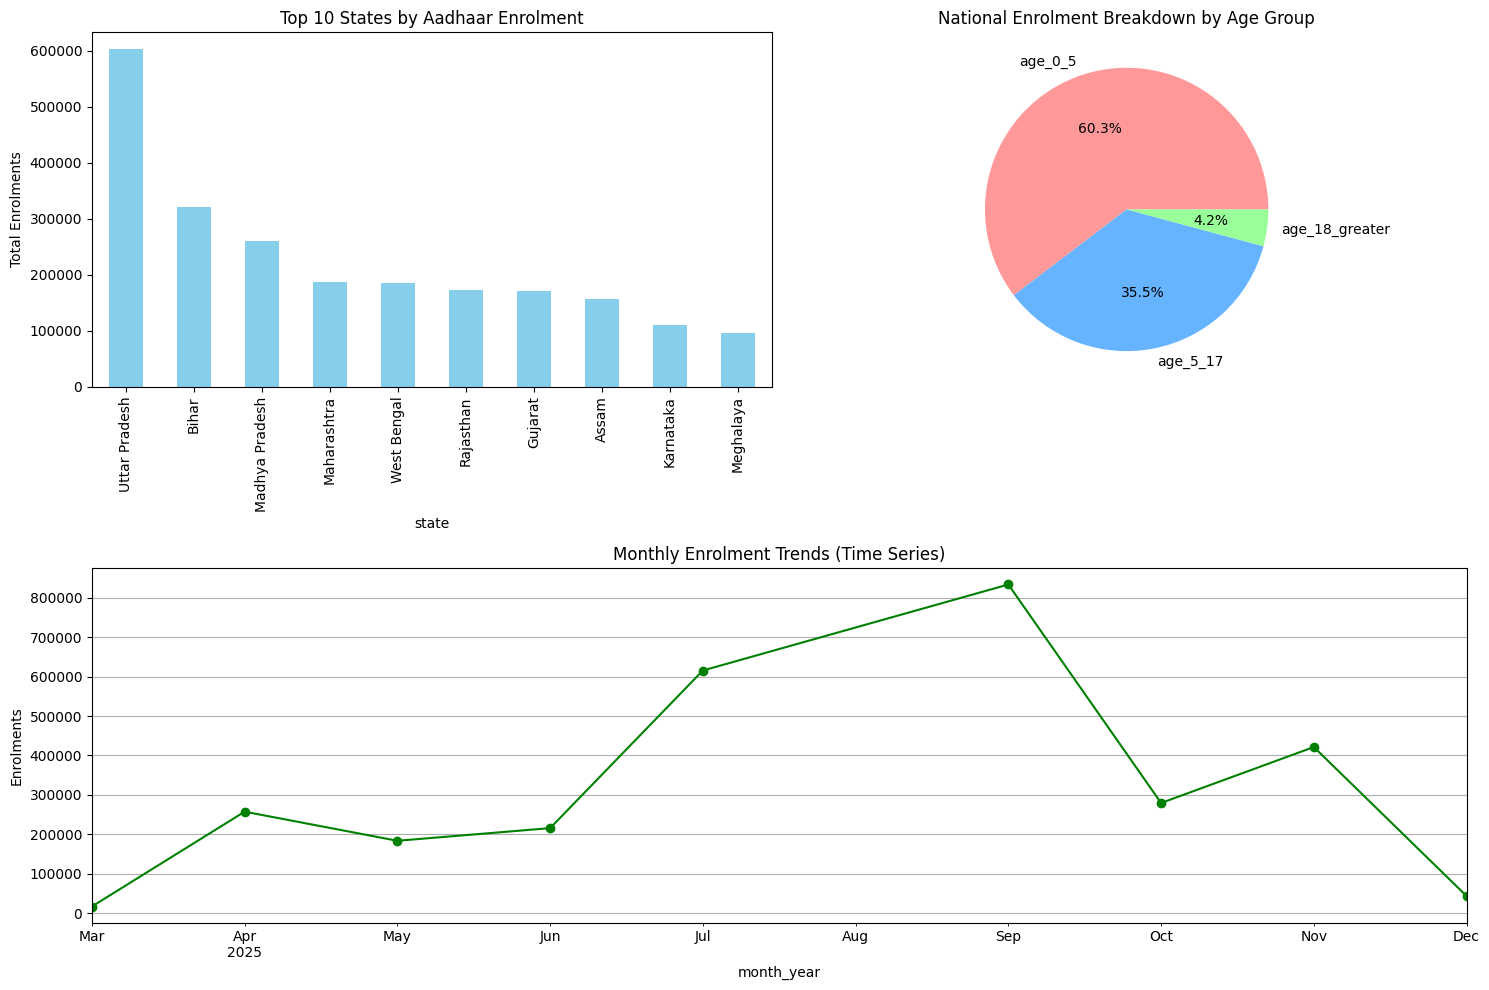

Top 10 Districts for Child Enrolment Focus:
state          district       
Maharashtra    Thane              16560.0
Bihar          Sitamarhi          15078.0
West Bengal    Murshidabad        13640.0
Karnataka      Bengaluru          12573.0
               Bengaluru Urban    12111.0
Rajasthan      Jaipur             11915.0
Telangana      Hyderabad          11710.0
Uttar Pradesh  Sitapur            11286.0
Maharashtra    Pune               11172.0
Uttar Pradesh  Bareilly           11121.0
Name: age_0_5, dtype: float64


In [8]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['total_enrolment'] = df['age_0_5'] + df['age_5_17'] + df['age_18_greater']

state_summary = df.groupby('state')['total_enrolment'].sum().sort_values(ascending=False).head(10)
demographic_totals = df[['age_0_5', 'age_5_17', 'age_18_greater']].sum()


df['month_year'] = df['date'].dt.to_period('M')
monthly_trend = df.groupby('month_year')['total_enrolment'].sum()

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
state_summary.plot(kind='bar', color='skyblue')
plt.title('Top 10 States by Aadhaar Enrolment')
plt.ylabel('Total Enrolments')

plt.subplot(2, 2, 2)
plt.pie(demographic_totals, labels=demographic_totals.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('National Enrolment Breakdown by Age Group')
plt.subplot(2, 1, 2)
monthly_trend.plot(kind='line', marker='o', color='green')
plt.title('Monthly Enrolment Trends (Time Series)')
plt.ylabel('Enrolments')
plt.grid(True)

plt.tight_layout()
plt.show()
priority_districts = df.groupby(['state', 'district'])['age_0_5'].sum().sort_values(ascending=False).head(10)
print("Top 10 Districts for Child Enrolment Focus:")
print(priority_districts)

In [9]:

df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['total_enrolment'] = df['age_0_5'] + df['age_5_17'] + df['age_18_greater']
df['month'] = df['date'].dt.month_name()
mobile_van_report = df.groupby(['state', 'district'])['total_enrolment'].sum().nlargest(15).reset_index()
mobile_van_report.to_csv('mobile_van_deployment_plan.csv', index=False)
child_gap = df.groupby(['state', 'district']).agg({
    'age_0_5': 'sum',
    'age_18_greater': 'sum'
}).reset_index()
child_gap['priority_score'] = (child_gap['age_0_5'] + 1) / (child_gap['age_18_greater'] + 1)
bal_aadhaar_report = child_gap[child_gap['age_18_greater'] > 500].nsmallest(15, 'priority_score')
bal_aadhaar_report.to_csv('bal_aadhaar_priority_zones.csv', index=False)

staffing_forecast = df.groupby('month')['total_enrolment'].sum().sort_values(ascending=False).reset_index()
staffing_forecast.to_csv('seasonal_staffing_calendar.csv', index=False)
localization_report = df.groupby('state')['total_enrolment'].sum().nlargest(5).reset_index()
localization_report.to_csv('language_localization_list.csv', index=False)

print("SUCCESS: All 4 Government Strategy Reports have been generated and saved as CSVs.")
print("\n--- Top 5 Districts for Mobile Van Surge ---")
print(mobile_van_report.head())

print("\n--- Top 5 Districts for Urgent Child Enrollment Awareness ---")
print(bal_aadhaar_report[['state', 'district', 'priority_score']].head())

/tmp/ipykernel_6073/3549914686.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'], dayfirst=True)
/tmp/ipykernel_6073/3549914686.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['total_enrolment'] = df['age_0_5'] + df['age_5_17'] + df['age_18_greater']
/tmp/ipykernel_6073/3549914686.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

SUCCESS: All 4 Government Strategy Reports have been generated and saved as CSVs.

--- Top 5 Districts for Mobile Van Surge ---
           state          district  total_enrolment
0          Bihar         Sitamarhi          32298.0
1  Uttar Pradesh          Bahraich          29772.0
2    Maharashtra             Thane          26761.0
3      Meghalaya  East Khasi Hills          25229.0
4      Karnataka   Bengaluru Urban          23074.0

--- Top 5 Districts for Urgent Child Enrollment Awareness ---
         state            district  priority_score
547  Meghalaya    South Garo Hills        0.396953
546  Meghalaya             Ri Bhoi        0.401742
541  Meghalaya    East Khasi Hills        0.447843
552  Meghalaya    West Khasi Hills        0.457167
540  Meghalaya  East Jaintia Hills        0.586317
